In [1]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()

In [4]:
print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [5]:
df_shallow['log_blue'] = np.log(df_shallow['blue_band'] + 1e-6)
df_shallow['log_green'] = np.log(df_shallow['green_band'] + 1e-6)
df_shallow['blue_green_ratio'] = df_shallow['blue_band'] / (df_shallow['green_band'] + 1e-6)
df_shallow['ndwi'] = (df_shallow['green_band'] - df_shallow['blue_band']) / (df_shallow['green_band'] + df_shallow['blue_band'] + 1e-6)

In [6]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

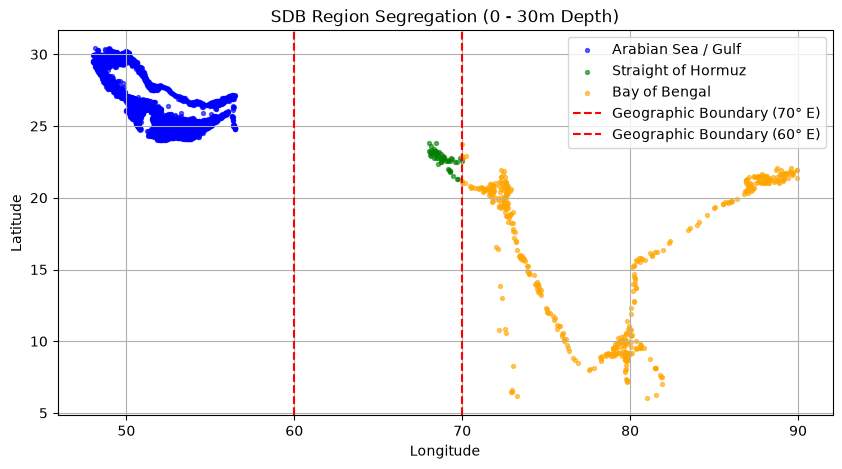

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
features = ['blue_band', 'green_band', 'log_blue', 'log_green', 'blue_green_ratio', 'ndwi']

In [9]:
X_all = df_shallow[features]
y_all = df_shallow['depth']

X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [11]:
scaler_global = StandardScaler()
X_tr_all_scaled = scaler_global.fit_transform(X_tr_all)
X_te_all_scaled = scaler_global.transform(X_te_all)

svr_global = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr_global.fit(X_tr_all_scaled, y_tr_all)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [12]:
y_pred_all = svr_global.predict(X_te_all_scaled)

In [13]:
mae_all = mean_absolute_error(y_te_all, y_pred_all)
rmse_all = root_mean_squared_error(y_te_all, y_pred_all)
r2_all = r2_score(y_te_all, y_pred_all)

print("=" * 45)
print("  SVR GLOBAL MODEL: ALL REGIONS")
print("=" * 45)
print(f"MAE  : {mae_all:.4f} m")
print(f"RMSE : {rmse_all:.4f} m")
print(f"R²   : {r2_all:.4f}\n")

  SVR GLOBAL MODEL: ALL REGIONS
MAE  : 4.7835 m
RMSE : 6.6035 m
R²   : 0.4464



  SVR SEPARATE REGIONAL MODELS
=== Arabian Sea / Gulf (N=4067) ===
  MAE  : 4.4987 m
  RMSE : 6.2262 m
  R²   : 0.4898

=== Strait of Hormuz (N=54) ===
  MAE  : 2.8558 m
  RMSE : 4.5554 m
  R²   : 0.4651

=== Bay of Bengal (N=427) ===
  MAE  : 4.9401 m
  RMSE : 6.5514 m
  R²   : 0.4168



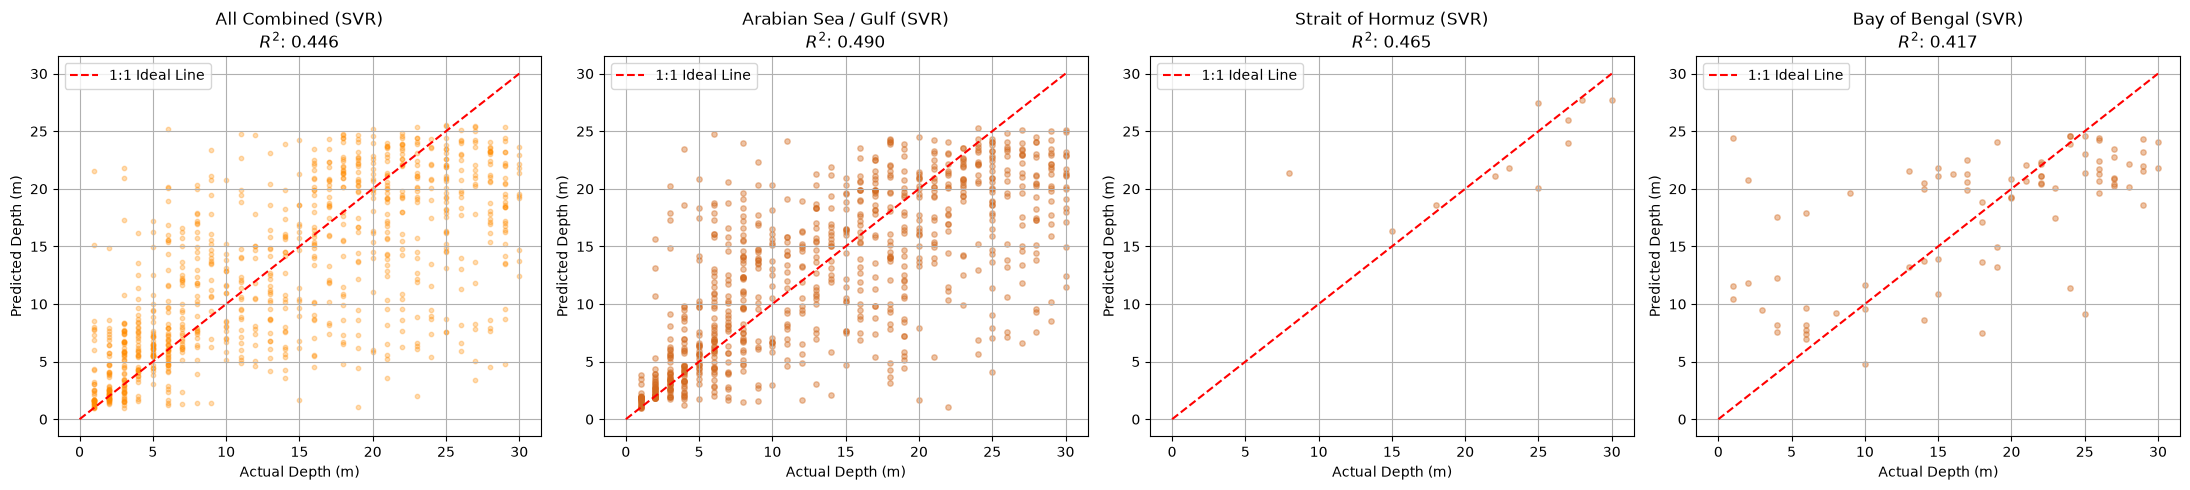

In [14]:
regions = [
    ('Arabian Sea / Gulf', df_arabian_sea),
    ('Strait of Hormuz', df_strait_of_hormuz),
    ('Bay of Bengal', df_bay_of_bengal)
]

svr_models = {}

print("=" * 45)
print("  SVR SEPARATE REGIONAL MODELS")
print("=" * 45)

# Setup subplots: 1 row with 4 plots (Combined + 3 Regions)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot Combined Results in First Subplot
axes[0].scatter(y_te_all, y_pred_all, alpha=0.3, s=10, color='darkorange')
axes[0].plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
axes[0].set_xlabel('Actual Depth (m)')
axes[0].set_ylabel('Predicted Depth (m)')
axes[0].set_title(f'All Combined (SVR)\n$R^2$: {r2_all:.3f}')
axes[0].grid(True)
axes[0].legend()

# Iterate through individual regions
for idx, (name, region_df) in enumerate(regions, start=1):
    if len(region_df) == 0:
        print(f"Skipping {name}: No samples available.")
        continue
        
    X_reg = region_df[features]
    y_reg = region_df['depth']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    
    # Fit StandardScaler independently per region to prevent data leakage
    scaler_region = StandardScaler()
    X_train_scaled = scaler_region.fit_transform(X_train)
    X_test_scaled = scaler_region.transform(X_test)
    
    # Fit individual SVR model
    svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
    svr.fit(X_train_scaled, y_train)
    svr_models[name] = svr
    
    # Predict & Evaluate
    y_pred = svr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {name} (N={len(region_df)}) ===")
    print(f"  MAE  : {mae:.4f} m")
    print(f"  RMSE : {rmse:.4f} m")
    print(f"  R²   : {r2:.4f}\n")
    
    # Plot Region Results
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='chocolate')
    ax.plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
    ax.set_title(f'{name} (SVR)\n$R^2$: {r2:.3f}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()